In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from scipy.optimize import curve_fit

#samples per second
sample_rate=10e6 #fill this in !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#skip the first x samples
start_sample=50e6 #fill this in !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#don't make sample step size too large. Steps in x samples 
sample_step_size=10e4 #fill this in !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#readout airspy1
airspy1 = np.fromfile("14nov_Airspy_1_to2_seperate_final",dtype=np.float32) #fill this in !!!!!!!!!!!!!!!!!!!!!!!!




In [ ]:
#readout airspy2
airspy2 = np.fromfile("14nov_Airspy_2_seperate_final",dtype=np.float32) #fill this in !!!!!!!!!!!!!!!!!!!!!!!!!!!!

#In start delay fill in the constant value you get from the (red) delay shift plot
start_delay=int(0) #fill this in !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
if start_delay>0:
    airspy1 = airspy1[start_delay:]
elif start_delay<0:
    airspy2 = airspy2[-start_delay:]
else:
    pass


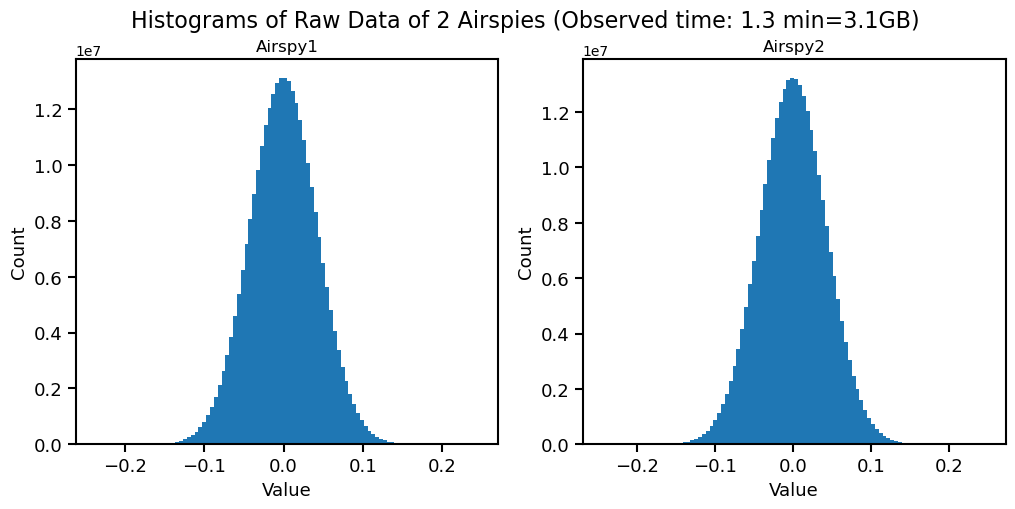

In [ ]:

fig, ax = plt.subplots(1,2)
fig.suptitle("Histograms of Raw Data of 2 Airspies (Observed time: 1.3 min=3.1GB)", fontsize=16)
ax[0].hist(airspy1, bins=100)
ax[1].hist(airspy2, bins=100)
ax[0].set_title("Airspy1")


ax[0].set_xlabel("Value", fontsize=13)
ax[0].set_ylabel("Count", fontsize=13)
for axis in 'left', 'bottom','right','top':
    ax[0].spines[axis].set_linewidth(1.5)
    ax[1].spines[axis].set_linewidth(1.5)
    ax[0].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

ax[1].set_title("Airspy2")
ax[1].set_xlabel("Value", fontsize=13)
ax[1].set_ylabel("Count", fontsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)


fig.set_figwidth(12)
fig.set_figheight(5)    
# plt.savefig("Raw_Airspies_histograms.pdf")

plt.show()

In [ ]:

airspy1_cut=airspy1[int(start_sample):int(start_sample+sample_step_size)]# 10million +100 thousand #cut out first 5 seconds
airspy2_cut=airspy2[int(start_sample):int(start_sample+sample_step_size)]
print(np.shape(airspy1_cut))
print(np.shape(airspy2_cut))
print(len(airspy1))
print(len(airspy2)) 
# print(776338432/(10e6*60)) #observed for only 1.3 minutes is 3.1 gb

(100000,)
(100000,)
287570944
287569920
1.2938973866666668


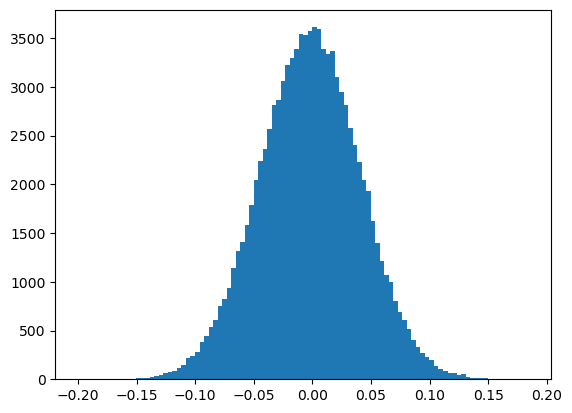

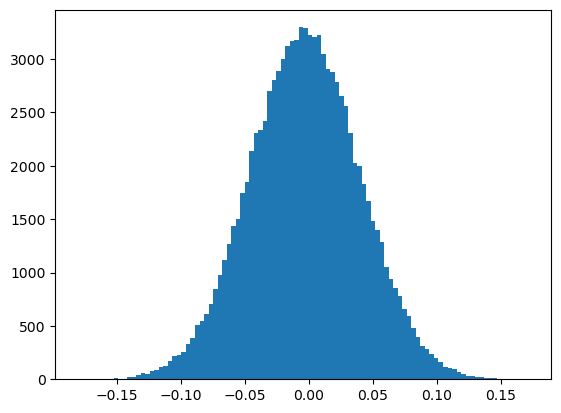

In [80]:
plt.hist(airspy1_cut, bins=100)
plt.show()
plt.hist(airspy2_cut, bins=100)
plt.show()

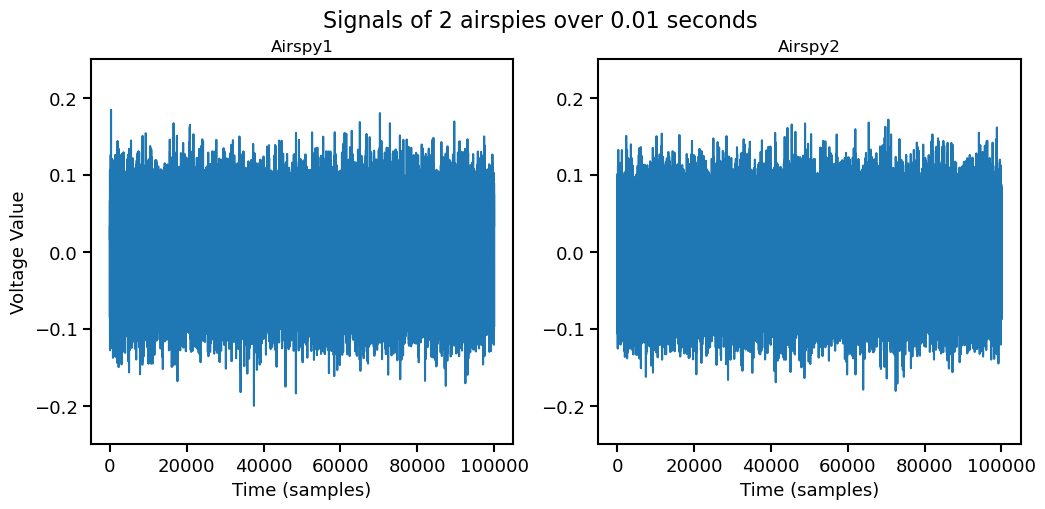

In [ ]:
samples_airspy_cut=np.arange(0,len(airspy1_cut),1)
fig, ax = plt.subplots(1,2)
fig.suptitle("Signals of 2 airspies over 0.01 seconds", fontsize=16)
ax[0].plot(samples_airspy_cut,airspy1_cut)
ax[1].plot(samples_airspy_cut,airspy2_cut)
ax[0].set_title("Airspy1")
# ax[0].set_xlim(0,0.0001)
ax[0].set_ylim(-0.25,0.25)
ax[0].set_xlabel("Time (samples)", fontsize=13)
ax[0].set_ylabel("Voltage Value", fontsize=13)
for axis in 'left', 'bottom','right','top':
    ax[0].spines[axis].set_linewidth(1.5)
    ax[1].spines[axis].set_linewidth(1.5)
    ax[0].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

ax[1].set_title("Airspy2")
ax[1].set_ylim(-0.25,0.25)
ax[1].set_xlabel("Time (samples)", fontsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

fig.set_figwidth(12)
fig.set_figheight(5)    
# plt.savefig("Signal_time_airspies.pdf")

plt.show()

(100000,)
50000.0


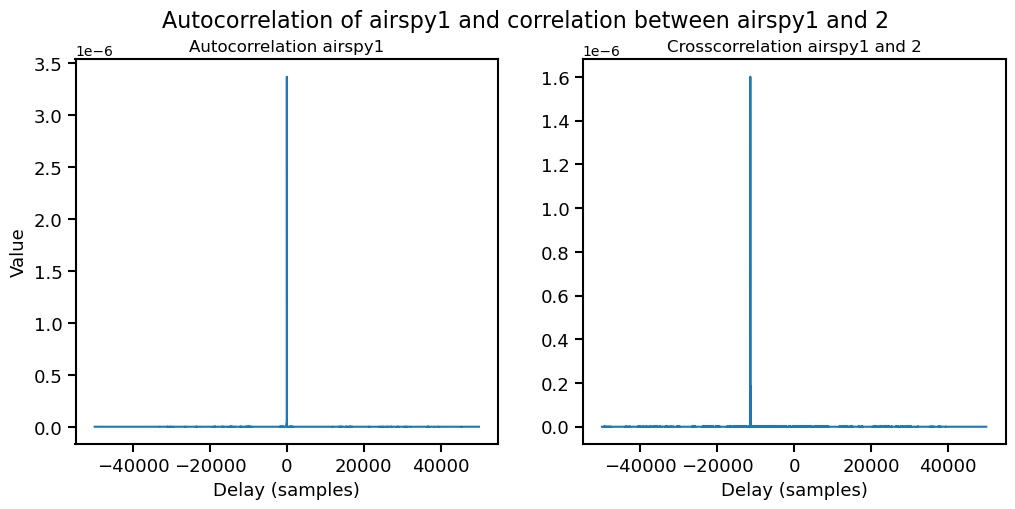

In [ ]:
correlate=scipy.signal.correlate(airspy1_cut,airspy2_cut, mode='same')/airspy1_cut.shape[0]
print(np.shape(correlate))
x=np.arange(0,len(correlate),1)
x_shift=samples_airspy_cut-samples_airspy_cut[len(samples_airspy_cut)//2]
print(len(x)/2)
auto_correlate=scipy.signal.correlate(airspy1_cut,airspy1_cut, mode='same')/airspy1_cut.shape[0]
fig, ax = plt.subplots(1,2)
fig.suptitle("Autocorrelation of airspy1 and correlation between airspy1 and 2", fontsize=16)
ax[0].plot(x_shift,auto_correlate**2)
ax[1].plot(x_shift,correlate**2)
ax[0].set_title("Autocorrelation airspy1")

ax[0].set_xlabel("Delay (samples)", fontsize=13)
ax[0].set_ylabel("Value", fontsize=13)
for axis in 'left', 'bottom','right','top':
    ax[0].spines[axis].set_linewidth(1.5)
    ax[1].spines[axis].set_linewidth(1.5)
    ax[0].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

# ax[0].legend(fontsize=12)
ax[1].set_title("Crosscorrelation airspy1 and 2")
# ax[1].set_xlim(11300,11500)

ax[1].set_xlabel("Delay (samples)", fontsize=13)

ax[1].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

fig.set_figwidth(12)
fig.set_figheight(5)    
# plt.savefig("no_delay_autocorellation_and_correlation_2_airspies.pdf")


5.0
100000


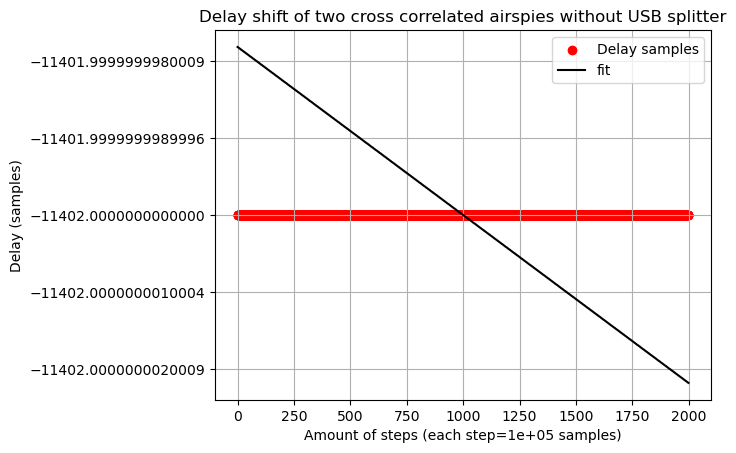

slope=-2.1796088072614785e-12 b=-11401.99999999782


In [ ]:


def func_line(x,a,b):
    return a*x+b

print(start_sample/sample_rate)
middle=sample_step_size/2
amount_steps=2000
sample_shift=np.zeros(amount_steps)
for i in range(amount_steps):
    airspy1_cut=airspy1[int(start_sample+(i*sample_step_size)):int(start_sample+((i+1)*sample_step_size))]# 
    airspy2_cut=airspy2[int(start_sample+(i*sample_step_size)):int(start_sample+((i+1)*sample_step_size))]
    correlate=scipy.signal.correlate(airspy1_cut,airspy2_cut, mode='same')/airspy1_cut.shape[0]
    x=np.arange(0,len(correlate),1)
    index_max=np.argmax(correlate**2)
    delta_x=index_max-middle
    sample_shift[i]=index_max-middle
# plt.xlim(20700,38000)
print(len(correlate))
sample_array=np.arange(0,amount_steps,1)
popt, pcov = curve_fit(func_line,sample_array,sample_shift)
x_fit=np.linspace(np.min(sample_array),np.max(sample_array),1000)
y_fit=func_line(x_fit,popt[0],popt[1])
plt.scatter(sample_array,sample_shift,color="red",label="Delay samples")
plt.plot(x_fit,y_fit,color="black",label="fit")
plt.xlabel("Amount of steps (each step="+(f'{sample_step_size:.3g}')+" samples)")
plt.ylabel("Delay (samples)")
plt.title("Delay shift of two cross correlated airspies without USB splitter")
plt.ticklabel_format(useOffset=False)
plt.legend()
# plt.savefig("zero_delay.pdf",bbox_inches="tight")
plt.grid()
plt.show()
print("slope="+str(popt[0])+" b="+str(popt[1]))




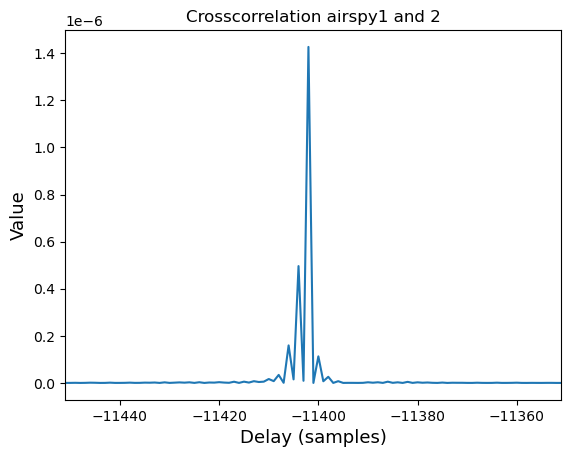

38598
-11402


In [ ]:

plt.plot(x_shift,correlate**2)
plt.title("Crosscorrelation airspy1 and 2")
plt.xlim((int(popt[1])-50),(int(popt[1])+50))
plt.xlabel("Delay (samples)", fontsize=13)
plt.ylabel("Value", fontsize=13)
plt.show()
print(np.argmax(correlate**2))
print(x_shift[np.argmax(correlate**2)])